<div style="background: linear-gradient(135deg, #1b5e20 0%, #2e7d32 50%, #388e3c 100%); padding: 40px 30px; border-radius: 12px; margin-bottom: 30px;">
  <h1 style="color:#ffffff; font-size:2.2em; font-weight:700; margin:0 0 10px 0;">Зертханалық Жұмыс 2</h1>
  <h2 style="color:#c8e6c9; font-size:1.4em; font-weight:400; margin:0 0 16px 0;">ALS — Alternating Least Squares</h2>
  <p style="color:#e8f5e9; font-size:1em; margin:0;">Matrix Factorization · Латентті Факторлар · Регуляризация · Гиперпараметрлер · Деректер сиректігі</p>
</div>

## Кіріспе

**Matrix Factorization** (MF) — рейтинг матрицасын екі кіші матрицаның көбейтіндісімен жуықтайды:

```
R ≈ U × Vᵀ
(n×m) ≈ (n×k) × (k×m)
```

Мұнда k — латентті факторлар саны. U-нің əр жолы — пайдаланушының латентті профилі, V-нің əр жолы — өнімнің латентті профилі.

**ALS** — U мен V-ді кезекпен оңтайландырады. Əр кезеңде бір матрица тіркеліп, екіншісі Least Squares-пен жаңартылады — əр қадам аналитикалық шешімге ие.

## Оқу Мақсаттары

- ALS алгоритмінің əр қадамын математикалық деңгейде түсіне аласыз
- n_factors, reg (λ), n_epochs гиперпараметрлерінің əсерін талдай аласыз
- Латентті факторларды PCA + t-SNE арқылы визуализациялай аласыз
- Сиректік пен ALS нəтижесінің байланысын зерттей аласыз
- SGD-негізді MF-мен ALS нəтижесін салыстыра аласыз

**Болжалды орындалу уақыты: 20 минут**

## 1-бөлім: Кітапханаларды Импорттау

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Кітапханалар жүктелді.")

Кітапханалар жүктелді.


## 2-бөлім: Деректерді Жасау

In [2]:
N_USERS, N_ITEMS = 150, 200
N_FACTORS_TRUE   = 6     # шынайы факторлар саны

# Шынайы латентті факторлар
true_U = np.random.randn(N_USERS, N_FACTORS_TRUE)
true_V = np.random.randn(N_ITEMS, N_FACTORS_TRUE)
true_R = true_U @ true_V.T

# [1, 5] диапазонына нормализация
true_R = 1 + 4 * (true_R - true_R.min()) / (true_R.max() - true_R.min())

# Сирек байқалатын рейтинг матрицасы (7% тығыздық)
mask = np.random.binomial(1, 0.07, (N_USERS, N_ITEMS)).astype(bool)
R    = np.where(mask, true_R + np.random.randn(N_USERS, N_ITEMS) * 0.2, 0.0)
R    = np.clip(R, 0, 5) * mask

print(f"Матрица: {N_USERS}×{N_ITEMS}, тығыздық={mask.mean():.2%}")
print(f"Белгілі рейтингтер: {mask.sum()}")

Матрица: 150×200, тығыздық=7.09%
Белгілі рейтингтер: 2127


## 3-бөлім: ALS Іске Асыру — Толық Нұсқа

Weighted ALS (WLS) шығын функциясы:
```
L = Σ_{(u,i)∈Ω} (r_ui - u_u · v_i)² + λ(||U||²_F + ||V||²_F)
```
Əр пайдаланушы жаңартуы — аналитикалық шешім:
```
u_u = (V_Ω.T V_Ω + λI)⁻¹ V_Ω.T r_Ω
```

In [3]:
class ALSFull:
    """
    Толық ALS іске асыруы:
    - Bias терминдері (пайдаланушы + өнім)
    - L2 регуляризация
    - Validation RMSE бақылауы
    """
    def __init__(self, n_factors=10, n_epochs=30, reg=0.1,
                 use_bias=True, random_state=42):
        self.n_factors    = n_factors
        self.n_epochs     = n_epochs
        self.reg          = reg
        self.use_bias     = use_bias
        self.random_state = random_state
        self.train_rmse_  = []
        self.val_rmse_    = []

    def _rmse(self, R, mask):
        R_pred = self.predict_all()
        err    = (R - R_pred) * mask
        return np.sqrt((err**2).sum() / (mask.sum() + 1e-10))

    def fit(self, R_train, R_val=None, mask_train=None, mask_val=None):
        rng    = np.random.RandomState(self.random_state)
        n_u, n_i = R_train.shape
        K        = self.n_factors

        if mask_train is None:
            mask_train = (R_train > 0).astype(np.float32)

        self.U_      = rng.randn(n_u, K) * 0.01
        self.V_      = rng.randn(n_i, K) * 0.01
        self.mu_     = R_train[mask_train > 0].mean()
        self.bu_     = np.zeros(n_u)
        self.bi_     = np.zeros(n_i)

        for epoch in range(self.n_epochs):
            # U жаңарту
            for u in range(n_u):
                rated = np.where(mask_train[u] > 0)[0]
                if len(rated) == 0:
                    continue
                V_r = self.V_[rated]
                if self.use_bias:
                    r_u = R_train[u, rated] - self.mu_ - self.bu_[u] - self.bi_[rated]
                else:
                    r_u = R_train[u, rated]
                A = V_r.T @ V_r + self.reg * np.eye(K)
                self.U_[u] = np.linalg.solve(A, V_r.T @ r_u)
                if self.use_bias:
                    residuals  = R_train[u, rated] - self.mu_ - self.V_[rated] @ self.U_[u] - self.bi_[rated]
                    self.bu_[u] = residuals.mean()

            # V жаңарту
            for i in range(n_i):
                raters = np.where(mask_train[:, i] > 0)[0]
                if len(raters) == 0:
                    continue
                U_r = self.U_[raters]
                if self.use_bias:
                    r_i = R_train[raters, i] - self.mu_ - self.bu_[raters] - self.bi_[i]
                else:
                    r_i = R_train[raters, i]
                A = U_r.T @ U_r + self.reg * np.eye(K)
                self.V_[i] = np.linalg.solve(A, U_r.T @ r_i)
                if self.use_bias:
                    residuals  = R_train[raters, i] - self.mu_ - self.U_[raters] @ self.V_[i] - self.bu_[raters]
                    self.bi_[i] = residuals.mean()

            # Train RMSE
            tr = self._rmse(R_train, mask_train)
            self.train_rmse_.append(tr)

            # Val RMSE
            if R_val is not None and mask_val is not None:
                vr = self._rmse(R_val, mask_val)
                self.val_rmse_.append(vr)

            if (epoch + 1) % 10 == 0:
                msg = f"  Дəуір {epoch+1:3d}: Train RMSE={tr:.4f}"
                if R_val is not None:
                    msg += f", Val RMSE={vr:.4f}"
                print(msg)

        return self

    def predict_all(self):
        R_pred = self.U_ @ self.V_.T
        if self.use_bias:
            R_pred += self.mu_ + self.bu_[:, None] + self.bi_[None, :]
        return np.clip(R_pred, 1, 5)

    def recommend(self, user_idx, R, top_n=10):
        scores  = self.predict_all()[user_idx]
        unrated = np.where(R[user_idx] == 0)[0]
        top_idx = unrated[np.argsort(scores[unrated])[::-1][:top_n]]
        return top_idx, scores[top_idx]

print("ALSFull класы анықталды.")

ALSFull класы анықталды.


In [4]:
# Train/Val бөлу: белгілі рейтингтердің 80/20
known_pairs = list(zip(*np.where(R > 0)))
np.random.shuffle(known_pairs)
split       = int(len(known_pairs) * 0.8)
train_pairs = known_pairs[:split]
val_pairs   = known_pairs[split:]

R_train    = np.zeros_like(R)
R_val      = np.zeros_like(R)
mask_train = np.zeros_like(R)
mask_val   = np.zeros_like(R)

for u, i in train_pairs:
    R_train[u, i]    = R[u, i]
    mask_train[u, i] = 1
for u, i in val_pairs:
    R_val[u, i]    = R[u, i]
    mask_val[u, i] = 1

print(f"Train: {mask_train.sum():.0f} рейтинг")
print(f"Val:   {mask_val.sum():.0f} рейтинг")

Train: 1701 рейтинг
Val:   426 рейтинг


In [5]:
# ============================================================
### TODO ###
# ALSFull моделін n_factors=10, n_epochs=30, reg=0.1 параметрімен
# үйретіңіз. R_val жəне mask_val беріңіз.
# ============================================================
print("ALS үйретілуде...")
als = ALSFull(n_factors=10, n_epochs=30, reg=0.1, use_bias=True)
als.fit(R_train, R_val=R_val, mask_train=mask_train, mask_val=mask_val)
print("Аяқталды.")

ALS үйретілуде...
  Дəуір  10: Train RMSE=0.0283, Val RMSE=0.5264
  Дəуір  20: Train RMSE=0.0245, Val RMSE=0.5276
  Дəуір  30: Train RMSE=0.0235, Val RMSE=0.5309
Аяқталды.


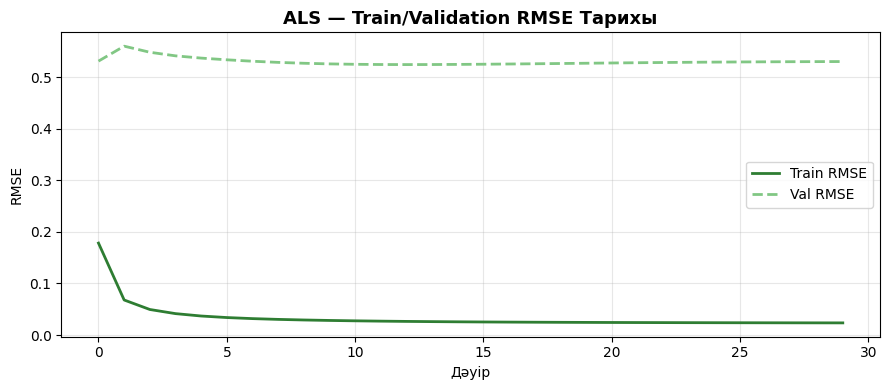

Соңғы Train RMSE: 0.0235
Соңғы Val RMSE:   0.5309


In [6]:
# ============================================================
### TODO ###
# Train жəне Validation RMSE тарихын бір графикте бейнелеңіз.
# als.train_rmse_ жəне als.val_rmse_ пайдаланыңыз.
# ============================================================
plt.figure(figsize=(9, 4))
plt.plot(als.train_rmse_, linewidth=2, color='#2e7d32', label='Train RMSE')   # als.train_rmse_
plt.plot(als.val_rmse_, linewidth=2, color='#81c784', linestyle='--', label='Val RMSE')  # als.val_rmse_
plt.title('ALS — Train/Validation RMSE Тарихы', fontsize=13, fontweight='bold')
plt.xlabel('Дəуір')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Соңғы Train RMSE: {als.train_rmse_[-1]:.4f}")
print(f"Соңғы Val RMSE:   {als.val_rmse_[-1]:.4f}")

## 4-бөлім: Гиперпараметрлер Іздеу

In [7]:
# ============================================================
### TODO ###
# Grid search: n_factors жəне reg гиперпараметрлерін іздеңіз.
# n_factors_list = [5, 10, 20, 40]
# reg_list       = [0.01, 0.1, 1.0]
# Əр комбинация үшін Val RMSE есептеп, ең жақсы параметрлерді табыңыз.
# ============================================================
n_factors_list = [5, 10, 20, 40]
reg_list       = [0.01, 0.1, 1.0]

results_grid = {}
print(f"{'n_factors':>10} {'reg':>8} {'Val RMSE':>10}")
print("-" * 32)

for nf in n_factors_list:
    for reg in reg_list:
        m = ALSFull(n_factors=nf, n_epochs=20, reg=reg, use_bias=True)   # nf, reg
        m.fit(R_train, R_val=R_val, mask_train=mask_train, mask_val=mask_val)
        val_rmse = m.val_rmse_[-1]
        results_grid[(nf, reg)] = val_rmse
        print(f"{nf:>10} {reg:>8.2f} {val_rmse:>10.4f}")

best_params = min(results_grid, key=results_grid.get)
print(f"\nΥздік параметрлер: n_factors={best_params[0]}, reg={best_params[1]}")
print(f"Үздік Val RMSE: {results_grid[best_params]:.4f}")

 n_factors      reg   Val RMSE
--------------------------------
  Дəуір  10: Train RMSE=0.0442, Val RMSE=0.7975
  Дəуір  20: Train RMSE=0.0288, Val RMSE=0.7852
         5     0.01     0.7852
  Дəуір  10: Train RMSE=0.0601, Val RMSE=0.6398
  Дəуір  20: Train RMSE=0.0485, Val RMSE=0.6495
         5     0.10     0.6495
  Дəуір  10: Train RMSE=0.2136, Val RMSE=0.5428
  Дəуір  20: Train RMSE=0.2069, Val RMSE=0.5374
         5     1.00     0.5374
  Дəуір  10: Train RMSE=0.0031, Val RMSE=0.6156
  Дəуір  20: Train RMSE=0.0024, Val RMSE=0.6048
        10     0.01     0.6048
  Дəуір  10: Train RMSE=0.0283, Val RMSE=0.5264
  Дəуір  20: Train RMSE=0.0245, Val RMSE=0.5276
        10     0.10     0.5276
  Дəуір  10: Train RMSE=0.1957, Val RMSE=0.5261
  Дəуір  20: Train RMSE=0.1922, Val RMSE=0.5218
        10     1.00     0.5218
  Дəуір  10: Train RMSE=0.0006, Val RMSE=0.4984
  Дəуір  20: Train RMSE=0.0009, Val RMSE=0.4918
        20     0.01     0.4918
  Дəуір  10: Train RMSE=0.0236, Val RMSE=0.5048

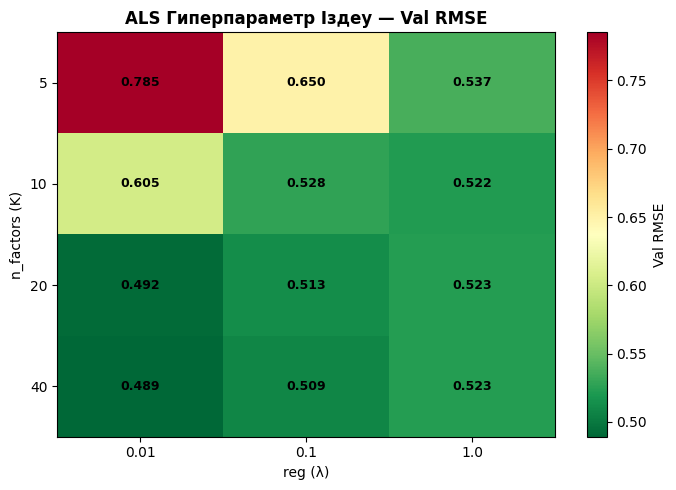

In [8]:
# Grid search нəтижесін жылу картасында бейнелейміз
grid_mat = np.array([[results_grid[(nf, reg)] for reg in reg_list]
                      for nf in n_factors_list])

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(grid_mat, cmap='RdYlGn_r', aspect='auto')
plt.colorbar(im, ax=ax, label='Val RMSE')
ax.set_xticks(range(len(reg_list)))
ax.set_yticks(range(len(n_factors_list)))
ax.set_xticklabels([str(r) for r in reg_list])
ax.set_yticklabels([str(n) for n in n_factors_list])
ax.set_xlabel('reg (λ)')
ax.set_ylabel('n_factors (K)')
ax.set_title('ALS Гиперпараметр Іздеу — Val RMSE',
             fontsize=12, fontweight='bold')

for i in range(len(n_factors_list)):
    for j in range(len(reg_list)):
        ax.text(j, i, f'{grid_mat[i,j]:.3f}',
                ha='center', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 5-бөлім: Латентті Факторларды Визуализациялау

In [9]:
# Үздік параметрлермен соңғы ALS үйрету
best_als = ALSFull(
    n_factors=best_params[0],
    n_epochs=30,
    reg=best_params[1],
    use_bias=True
)
best_als.fit(R_train, R_val=R_val, mask_train=mask_train, mask_val=mask_val)
print(f"Үздік модель Val RMSE: {best_als.val_rmse_[-1]:.4f}")

  Дəуір  10: Train RMSE=0.0004, Val RMSE=0.4890
  Дəуір  20: Train RMSE=0.0007, Val RMSE=0.4892
  Дəуір  30: Train RMSE=0.0010, Val RMSE=0.4899
Үздік модель Val RMSE: 0.4899


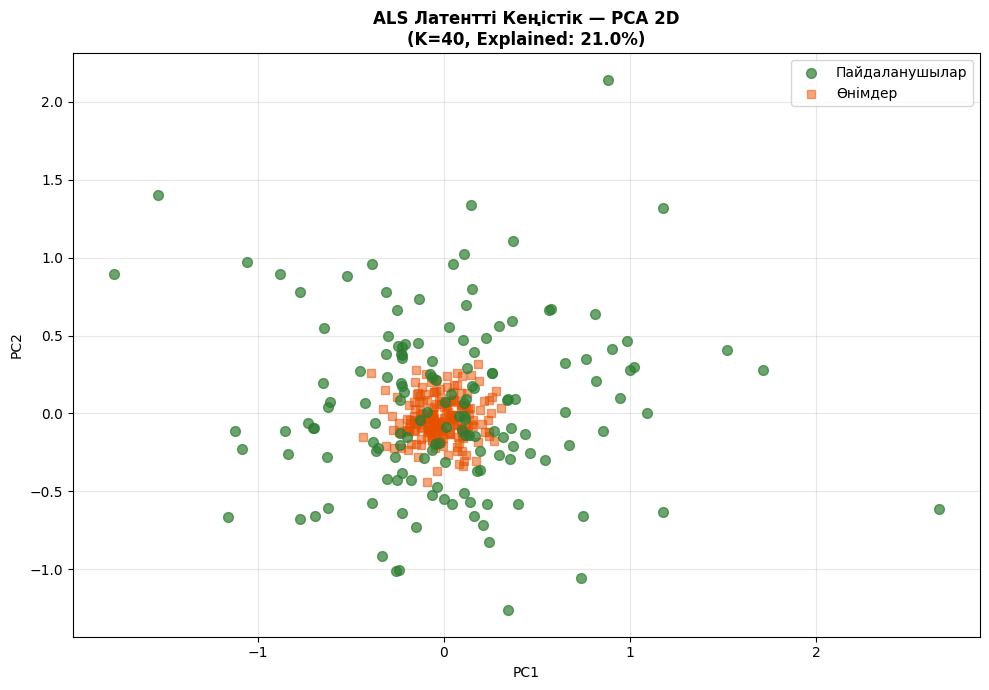

In [10]:
# ============================================================
### TODO ###
# PCA(n_components=2) арқылы пайдаланушы (U) жəне өнім (V)
# факторларын 2D-де бейнелеңіз.
# best_als.U_ жəне best_als.V_ пайдаланыңыз.
# ============================================================
pca = PCA(n_components=2, random_state=42)

# Пайдаланушы жəне өнімдерді бірге PCA жасаймыз
all_factors = np.vstack([best_als.U_, best_als.V_])
all_2d      = pca.fit_transform(all_factors)


user_2d = all_2d[:N_USERS]
item_2d = all_2d[N_USERS:]

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(user_2d[:, 0], user_2d[:, 1], c='#2e7d32',
           s=50, alpha=0.7, label='Пайдаланушылар', zorder=5)
ax.scatter(item_2d[:, 0], item_2d[:, 1], c='#e65100',
           s=30, alpha=0.5, label='Өнімдер', marker='s', zorder=4)
ax.set_title(
    f'ALS Латентті Кеңістік — PCA 2D\n'
    f'(K={best_params[0]}, Explained: {pca.explained_variance_ratio_.sum():.1%})',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

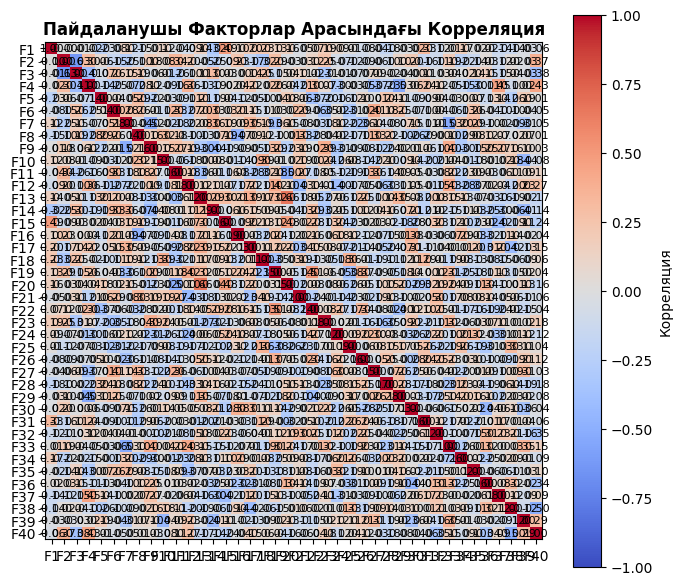

In [11]:
# Факторлар арасындағы корреляция матрицасы
factor_corr = np.corrcoef(best_als.U_.T)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(factor_corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Корреляция')
ax.set_title('Пайдаланушы Факторлар Арасындағы Корреляция',
             fontsize=12, fontweight='bold')
K_best = best_params[0]
ax.set_xticks(range(K_best))
ax.set_yticks(range(K_best))
ax.set_xticklabels([f'F{i+1}' for i in range(K_best)])
ax.set_yticklabels([f'F{i+1}' for i in range(K_best)])
for i in range(K_best):
    for j in range(K_best):
        ax.text(j, i, f'{factor_corr[i,j]:.2f}',
                ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 6-бөлім: SGD-негізді MF мен ALS Салыстыруы

In [12]:
class SGDMF:
    """
    Stochastic Gradient Descent Matrix Factorization.
    ALS-пен салыстыру үшін.
    """
    def __init__(self, n_factors=10, n_epochs=30, lr=0.01, reg=0.1,
                 random_state=42):
        self.n_factors    = n_factors
        self.n_epochs     = n_epochs
        self.lr           = lr
        self.reg          = reg
        self.random_state = random_state
        self.train_rmse_  = []
        self.val_rmse_    = []

    def fit(self, R_train, R_val=None, mask_train=None, mask_val=None):
        rng    = np.random.RandomState(self.random_state)
        n_u, n_i = R_train.shape
        K        = self.n_factors

        if mask_train is None:
            mask_train = (R_train > 0).astype(float)

        self.U_  = rng.randn(n_u, K) * 0.01
        self.V_  = rng.randn(n_i, K) * 0.01
        self.mu_ = R_train[mask_train > 0].mean()

        pairs = list(zip(*np.where(mask_train > 0)))

        for epoch in range(self.n_epochs):
            rng.shuffle(pairs)
            for u, i in pairs:
                r_ui = R_train[u, i]
                err  = r_ui - (self.mu_ + self.U_[u] @ self.V_[i])
                # SGD жаңарту
                self.U_[u] += self.lr * (err * self.V_[i] - self.reg * self.U_[u])
                self.V_[i] += self.lr * (err * self.U_[u] - self.reg * self.V_[i])

            R_pred = np.clip(self.mu_ + self.U_ @ self.V_.T, 1, 5)
            tr_err = ((R_train - R_pred) * mask_train) ** 2
            self.train_rmse_.append(np.sqrt(tr_err.sum() / mask_train.sum()))

            if R_val is not None and mask_val is not None:
                vl_err = ((R_val - R_pred) * mask_val) ** 2
                self.val_rmse_.append(np.sqrt(vl_err.sum() / mask_val.sum()))

        return self

print("SGDMF класы анықталды.")

SGDMF класы анықталды.


SGD MF үйретілуде...
Аяқталды.


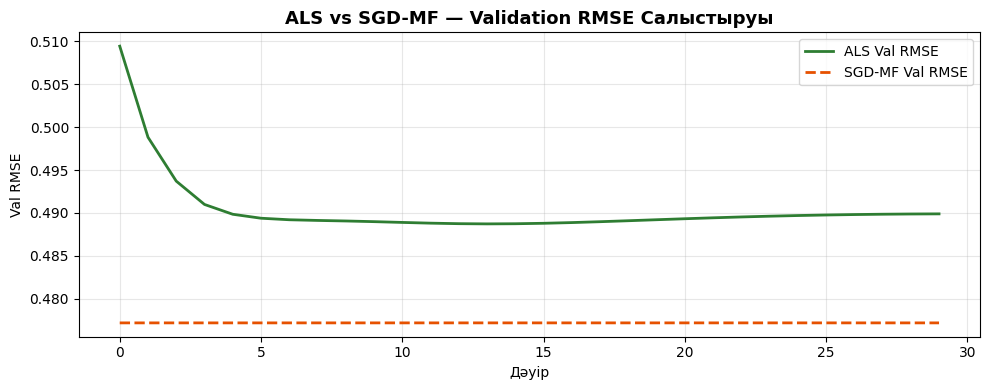

ALS соңғы Val RMSE:    0.4899
SGD-MF соңғы Val RMSE: 0.4772


In [13]:
# ============================================================
### TODO ###
# SGDMF моделін n_factors=best_params[0], n_epochs=30,
# lr=0.01, reg=best_params[1] параметрлерімен үйретіңіз.
# ALS пен SGD Val RMSE тарихтарын бір графикте салыстырыңыз.
# ============================================================
print("SGD MF үйретілуде...")
sgd = SGDMF(
    n_factors= best_params[0], n_epochs=30, lr=0.01, reg=best_params[1]   # best_params[0], best_params[1]
)
sgd.fit(R_train, R_val=R_val, mask_train=mask_train, mask_val=mask_val)
print("Аяқталды.")

plt.figure(figsize=(10, 4))
plt.plot(best_als.val_rmse_, linewidth=2, color='#2e7d32', label=f'ALS Val RMSE')
plt.plot(sgd.val_rmse_,      linewidth=2, color='#e65100', label=f'SGD-MF Val RMSE', linestyle='--')
plt.title('ALS vs SGD-MF — Validation RMSE Салыстыруы', fontsize=13, fontweight='bold')
plt.xlabel('Дəуір')
plt.ylabel('Val RMSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ALS соңғы Val RMSE:    {best_als.val_rmse_[-1]:.4f}")
print(f"SGD-MF соңғы Val RMSE: {sgd.val_rmse_[-1]:.4f}")

## 7-бөлім: Рефлексиялық Сұрақтар

**Сұрақ 1.** ALS-тің SGD-ға қарағандағы негізгі артықшылығы неде? Қай жағдайда SGD артықшылықты болады?

> ALS тезірек және тұрақтырақ жұмыс істейді, өйткені әр қадамда ең жақсы шешімді бірден табады. Сонымен қатар оны бірнеше процессормен қатар есептеуге болады.
SGD өте үлкен немесе үнемі жаңарып тұратын деректермен жұмыс істегенде тиімді, себебі деректерді біртіндеп өңдейді және аз жады қажет етеді.

**Сұрақ 2.** n_factors (K) өте үлкен болса модельге қандай əсер болады? Оны регуляризация шешеді ме?

> K тым үлкен болса, модель деректерді жаттап алып, жаңа деректерде нашар нәтиже көрсетуі мүмкін (overfitting).
Регуляризация бұл мәселені азайтады, бірақ толық жоймайды. Сондықтан K мен регуляризация параметрін бірге дұрыс таңдау керек.

**Сұрақ 3.** Латентті факторлар визуализациясында кластерлер байқалды ма? Бұл нені білдіреді?

> Кластерлер болса, бұл ұқсас пайдаланушылар немесе ұқсас өнімдер бір топқа жиналғанын білдіреді. Яғни модель олардың арасындағы ұқсастықтарды дұрыс анықтай алған.

**Сұрақ 4.** Bias терминдері (bu, bi) ALS нəтижесін қалай жақсартады? Оларды алып тастасақ не болады?

> Bias пайдаланушылардың әдеттегі бағалау стилін және өнімдердің жалпы танымалдылығын ескереді. Соның арқасында модель дәлірек жұмыс істейді.
Егер bias-тарды алып тастасақ, модель бұл айырмашылықтарды өзі үйренуге тырысады, нәтижесінде қателік көбейіп, болжам сапасы төмендеуі мүмкін.

## Қорытынды

Осы зертханада сіз ALS-тің аналитикалық жаңарту формуласын іске асырдыңыз, Train/Validation бөлумен RMSE динамикасын бақыладыңыз, Grid search арқылы n_factors мен reg гиперпараметрлерін оңтайландырдыңыз, латентті факторларды PCA арқылы 2D-де визуализациялауды орындадыңыз, жəне SGD-MF-пен конвергенция жылдамдығын салыстырдыңыз.

<div style="background-color:#e8f5e9; border-left:5px solid #2e7d32; padding:12px 16px; border-radius:6px; margin-top:16px;">
<strong>Келесі қадам:</strong> Зертханалық Жұмыс 3 — SLIM əдісі жəне Implicit Feedback.
</div>